# NeuroQA Phase 1 — an endpoint-aware contamination score, tested against a real depression marker

**One-sentence version:** don't build a classifier, don't build a cleaner — detect artifacts with
MNE, score each one by how much its frequency band overlaps the band we're about to measure, and
use that score to test whether a known depression marker (frontal alpha asymmetry, FAA) is partly
contamination.

This notebook runs the whole Phase 1 pipeline end to end: **data loader** → **endpoint-aware
quality index** → **FAA** → **Test A** (does cleaning choice decide the FAA-group answer?) →
**Test B.1** (is contamination itself tied to diagnosis?) → **Test B.2** (does contamination alone
predict diagnosis?). Seeded throughout (fixed `random_state` in every stochastic step — ICA,
autoreject, cross-validation); re-running this notebook on the same public dataset reproduces the
same numbers. Cells that are slow (loader, preprocessing, Study A) reuse this repo's cached
`outputs/*.csv` when present instead of recomputing — delete `neuroqa/outputs/` to force a full
from-scratch run.

**Dataset:** HUSM/Mumtaz resting-state EEG, healthy vs. MDD, 19-channel 10-20 montage, raw (not
pre-cleaned), includes F3/F4, group label (H/MDD) from outside the EEG.

**Read this before the numbers below:** `WEIGHT[artifact.type]` and the artifact/endpoint overlap
logic are domain calls — supplied as placeholders here (`bands.py`), pending the real
physics-derived values. Nothing in this notebook or the rest of the repo tunes them against an
accuracy number. See the Caveats section at the end for what that means for interpreting the
results below.

In [1]:
import sys
from pathlib import Path

# nbconvert executes with the *notebook file's* directory as cwd
# (neuroqa/notebooks/), not neuroqa/ itself -- resolve neuroqa/ explicitly
# so `import ingest` etc. and the outputs/ path both work regardless of
# where this notebook is launched from.
NEUROQA_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(NEUROQA_DIR))

SEED = 0
import numpy as np
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
%matplotlib inline

OUT_DIR = NEUROQA_DIR / "outputs"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("neuroqa dir:", NEUROQA_DIR)
print("outputs dir:", OUT_DIR)

neuroqa dir: C:\Users\RyanC\Documents\MLCANCERMODEL\neuroqa
outputs dir: C:\Users\RyanC\Documents\MLCANCERMODEL\neuroqa\outputs


## 1. Data loader

Public, **labeled** (H vs MDD, from outside the EEG), **raw** (not pre-cleaned) resting-state EEG,
19-channel 10-20 montage including F3/F4. `ingest.py` validates channel coverage and sample rate,
and flags this dataset's known byte-identical duplicate recordings (excluded later by md5 before
any group-level statistic).

In [2]:
manifest_path = OUT_DIR / "ingest_manifest.csv"
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    print(f"loaded cached {manifest_path}")
else:
    from ingest import ingest
    manifest = ingest()
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    manifest.to_csv(manifest_path, index=False)
    print(f"built fresh -> {manifest_path}")

n_ok = int((manifest.channels_ok & manifest.sfreq_ok).sum())
print(f"{len(manifest)} resting-state recordings "
      f"(H={int((manifest.group=='H').sum())}, MDD={int((manifest.group=='MDD').sum())}), "
      f"{n_ok} pass channel/sfreq checks, {int(manifest.is_duplicate.sum())} byte-identical duplicates flagged")
manifest.head()

loaded cached C:\Users\RyanC\Documents\MLCANCERMODEL\neuroqa\outputs\ingest_manifest.csv
120 resting-state recordings (H=58, MDD=62), 120 pass channel/sfreq checks, 10 byte-identical duplicates flagged


,file,group,subject,condition,path,load_error,n_channels,sfreq,channels_ok,missing_channels,sfreq_ok,duration_sec,md5,is_duplicate
0,6921143_H S15 EO.edf,H,15,EO,C:\Users\RyanC\Documents\MLCANCERMODEL\v1\Data...,NaN,22,256.0,True,NaN,True,302.0,0740579755f752a9e1abf4ca286ec35d,True
1,6921959_H S15 EO.edf,H,15,EO,C:\Users\RyanC\Documents\MLCANCERMODEL\v1\Data...,NaN,22,256.0,True,NaN,True,302.0,0740579755f752a9e1abf4ca286ec35d,True
2,H S1 EC.edf,H,1,EC,C:\Users\RyanC\Documents\MLCANCERMODEL\v1\Data...,NaN,22,256.0,True,NaN,True,300.0,1dc454cf1c06402b78264c1bcbe39086,False
3,H S1 EO.edf,H,1,EO,C:\Users\RyanC\Documents\MLCANCERMODEL\v1\Data...,NaN,22,256.0,True,NaN,True,351.0,a5c5c64d8303022567c72b9c3fb6f909,False
4,H S10 EC.edf,H,10,EC,C:\Users\RyanC\Documents\MLCANCERMODEL\v1\Data...,NaN,22,256.0,True,NaN,True,376.0,50fc93e07a3784c30800564674868026,False


**Severity scores** (`artifact.severity` in the brief's pseudocode) come from the Step 3 detectors
(`artifact_detectors.py`) — each returns a continuous severity in [0, 1] per epoch x channel, which
Test B.1 needs (as `raw_severity_mean`, the endpoint-independent mean across all six).

In [3]:
from artifact_detectors import DETECTORS
print("detectors (each: per-epoch, per-channel severity in [0, 1]):", list(DETECTORS.keys()))

detectors (each: per-epoch, per-channel severity in [0, 1]): ['eog', 'emg', 'pop', 'line_noise', 'motion', 'cardiac']


## 2. The endpoint-aware quality index

```
for artifact in detected_artifacts(recording):      # MNE-style detection, artifact_detectors.py
    overlap = spectral_overlap(artifact.band, ENDPOINT_BAND)
    penalty += artifact.severity * WEIGHT[artifact.type] * overlap
quality = f(penalty)
```

Proof the endpoint-aware design actually does what it claims: a synthetic, maximally-severe blink
scores completely differently depending on which band you ask about.

In [4]:
from bands import EEG_BANDS, ARTIFACT_BANDS, WEIGHT, spectral_overlap
from quality_index import contributions, penalty_from_contributions, quality_from_penalty

synthetic = {name: np.zeros((1, 1)) for name in ARTIFACT_BANDS}
synthetic["eog"][:] = 1.0  # a maximally-severe, fully-detected blink, and nothing else
for band_name in ["delta", "alpha"]:
    c = contributions(synthetic, EEG_BANDS[band_name])
    q = quality_from_penalty(penalty_from_contributions(c))
    print(f"  same blink, scored against {band_name:6s}: quality = {q.item():5.1f}%")

print("\nWEIGHT (placeholder -- equal weighting, pending Peter's derived values):")
print(WEIGHT)

  same blink, scored against delta : quality =  36.8%
  same blink, scored against alpha : quality = 100.0%

WEIGHT (placeholder -- equal weighting, pending Peter's derived values):
{'eog': 1.0, 'emg': 1.0, 'pop': 1.0, 'line_noise': 1.0, 'motion': 1.0, 'cardiac': 1.0}


**Caveat worth flagging to Peter, not silently fixed here:** `ARTIFACT_BANDS["emg"] = (20, 45)` Hz
has **zero** `spectral_overlap` with alpha (8-13 Hz) under the current placeholder bands — detected
muscle artifact currently contributes *nothing* to the alpha-endpoint quality score. That's in
tension with the brief's own stated hypothesis ("muscle noise sitting at the same frequency as
alpha"). Artifact-band assignment is a domain call, not mine to widen just to make the hypothesis
land — but it means: if real EMG contamination does extend into alpha, the quality-vs-alpha numbers
in Test B below likely *underestimate* muscle contamination there. Confirm with Peter before
treating Test B's alpha-quality results as a clean test of the EMG-alpha overlap claim.

In [5]:
print(f"spectral_overlap(EMG band {ARTIFACT_BANDS['emg']}, alpha {EEG_BANDS['alpha']}) = "
      f"{spectral_overlap(ARTIFACT_BANDS['emg'], EEG_BANDS['alpha']):.3f}   <- 0.0, see caveat above")

spectral_overlap(EMG band (20.0, 45.0), alpha (8.0, 13.0)) = 0.000   <- 0.0, see caveat above


Run the quality index over every recording (filter + epoch, then score all 5 canonical bands).

In [6]:
quality_path = OUT_DIR / "quality_summary.csv"
if quality_path.exists():
    quality_summary = pd.read_csv(quality_path)
    print(f"loaded cached {quality_path}")
else:
    import preprocess, score
    preprocess.main()
    score.main()
    quality_summary = pd.read_csv(quality_path)
    print(f"computed fresh -> {quality_path}")

print(f"\n{len(quality_summary)} recordings scored")
band_cols = [c for c in quality_summary.columns if c.startswith("quality_") and c.endswith("_pct")]
print("mean quality_pct by endpoint band (the score moving with the endpoint is the whole point):")
print(quality_summary[band_cols].mean().round(1).to_string())

loaded cached C:\Users\RyanC\Documents\MLCANCERMODEL\neuroqa\outputs\quality_summary.csv

120 recordings scored
mean quality_pct by endpoint band (the score moving with the endpoint is the whole point):
quality_delta_pct    61.6
quality_theta_pct    97.6
quality_alpha_pct    97.0
quality_beta_pct     77.5
quality_gamma_pct    72.8


## 3. FAA computation

`FAA = ln(alpha power at F4) - ln(alpha power at F3)`, alpha = 8-13 Hz.

In [7]:
faa_path = OUT_DIR / "faa_summary.csv"
if faa_path.exists():
    faa_summary = pd.read_csv(faa_path)
    print(f"loaded cached {faa_path}")
else:
    import faa as faa_module
    faa_module.main()
    faa_summary = pd.read_csv(faa_path)
    print(f"computed fresh -> {faa_path}")

faa_summary.groupby("group").faa.agg(["mean", "std", "count"])

loaded cached C:\Users\RyanC\Documents\MLCANCERMODEL\neuroqa\outputs\faa_summary.csv


,mean,std,count
group,,,
H,0.248557,0.460465,58
MDD,0.060956,0.115400,62


## 4. Test A — does cleaning choice decide the FAA-group answer?

FAA under ~5 preprocessing pipelines (raw, ICA, generic amplitude rejection, autoreject, **ours** —
the endpoint-conditional scorer wired to *weight* instead of *measure*, i.e. the same idea as the
quality index, used to clean rather than measure) x 2 reference schemes (original/linked-ears vs.
average). Runs on a bounded subsample — ICA + autoreject are slow per recording; see `study_a.py`'s
own docstring for the runtime tradeoff and how to widen it.

**Red flag this test is checking for:** a big swing in the depressed-vs-healthy FAA difference
across pipeline/reference choices would mean processing decisions, not biology, are steering the
answer.

In [8]:
study_a_path = OUT_DIR / "study_a_faa_wide.csv"
if study_a_path.exists():
    study_a_wide = pd.read_csv(study_a_path)
    print(f"loaded cached {study_a_path}")
else:
    import study_a
    study_a.main()
    study_a_wide = pd.read_csv(study_a_path)
    print(f"computed fresh -> {study_a_path}")

display(study_a_wide)
print(f"\nFAA range across the 10 pipeline x reference combinations, per subject: "
      f"median {study_a_wide.faa_range.median():.3f}, max {study_a_wide.faa_range.max():.3f}")

loaded cached C:\Users\RyanC\Documents\MLCANCERMODEL\neuroqa\outputs\study_a_faa_wide.csv


,file,group,subject,autoreject_average,autoreject_original,generic_average,generic_original,ica_average,ica_original,ours_average,ours_original,raw_average,raw_original,faa_range,faa_std
0,H S1 EC.edf,H,1,0.294302,0.173729,0.298404,0.172048,0.295020,0.166716,0.289381,0.158848,0.289788,0.158894,0.139556,0.069411
1,H S10 EC.edf,H,10,-0.059149,0.067564,-0.057528,0.059778,-0.057528,0.057545,-0.057932,0.057766,-0.057528,0.057545,0.126713,0.070161
2,H S11 EC.edf,H,11,0.086666,0.017626,0.085654,0.010376,0.086842,0.010270,0.086771,0.010291,0.086842,0.010270,0.076573,0.038354
3,H S13 EC.edf,H,13,-0.195658,0.644412,-0.194001,0.655254,-0.308380,0.437379,-0.298012,0.455305,-0.308380,0.437379,0.963635,0.473472
4,H S14 EC.edf,H,14,-0.261534,0.149648,-0.261534,-0.043799,-0.261534,-0.043799,-0.261556,-0.043746,-0.261534,-0.043799,0.411205,0.215380
5,H S15 EC.edf,H,15,0.220879,0.751893,0.577369,0.803726,0.585372,0.834914,0.576873,0.804168,0.577369,0.803726,0.614035,0.179198
6,MDD S1 EC.edf,MDD,1,0.046965,-0.200955,0.014194,-0.224397,0.068450,-0.047476,0.011366,-0.126840,0.008493,-0.119474,0.292847,0.144721
7,MDD S10 EC.edf,MDD,10,0.033291,-0.070633,0.042742,-0.062741,0.042742,-0.061765,0.043331,-0.061343,0.042742,-0.061765,0.113964,0.064632
8,MDD S11 EC.edf,MDD,11,0.161833,-0.005280,0.159054,-0.004762,0.201863,0.025091,0.158728,-0.004022,0.159054,-0.003810,0.207143,0.092296
9,MDD S13 EC.edf,MDD,13,0.034723,0.043453,0.018785,0.057886,0.003922,0.042168,0.019441,0.050071,0.018785,0.048734,0.053965,0.017752



FAA range across the 10 pipeline x reference combinations, per subject: median 0.173, max 0.964


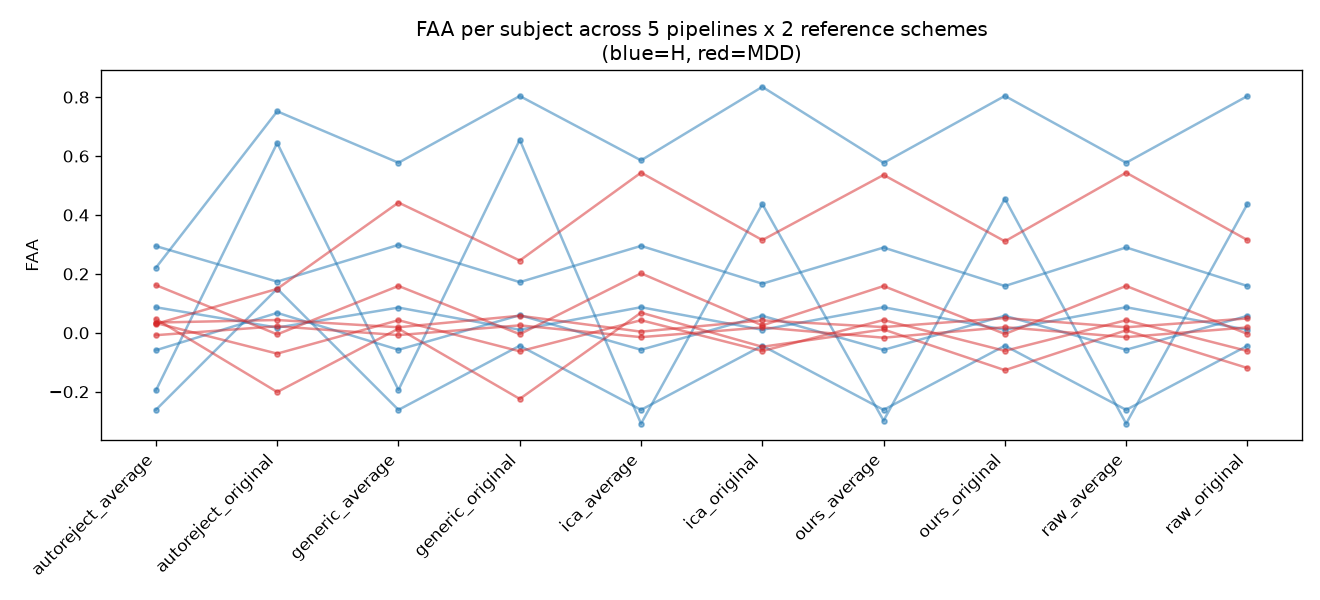

In [9]:
fig_path = FIG_DIR / "study_a_faa_spread.png"
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    print("(figure not found -- run study_a.py first)")

## 5. Test B — is contamination tied to diagnosis?

- **B.1**: `quality ~ group + severity` — is contamination itself different between groups, once raw
  artifact severity is accounted for? Red flag: group predicts contamination.
- **B.2 (the sharp one)**: `quality alone -> group`, strict cross-validated classifier (no
  normalization step exists to leak — see `study_b.regression_3`, which fits inside each CV fold via
  `cross_val_predict`) — can contamination *alone*, no brain-signal features, predict diagnosis
  above chance? Red flag: yes.
- (Third regression, `FAA ~ group + quality`, checks whether quality confounds the FAA-group
  relationship that's the actual reason FAA gets computed in the first place.)

In [10]:
import study_b

df_b = study_b.load_merged()
print(f"Study B sample: {len(df_b)} recordings ({df_b.group.value_counts().to_dict()}), "
      f"condition=EC, deduplicated by md5")

m1 = study_b.regression_1(df_b)  # quality ~ group + severity   (Test B.1)
m2 = study_b.regression_2(df_b)  # FAA ~ group + quality
r3 = study_b.regression_3(df_b)  # quality alone -> group        (Test B.2)

print("\n--- Test B.1: quality[alpha] ~ group + raw_severity_mean ---")
display(m1.summary())

Study B sample: 56 recordings ({'MDD': 29, 'H': 27}), condition=EC, deduplicated by md5

--- Test B.1: quality[alpha] ~ group + raw_severity_mean ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      quality_alpha_pct   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     13.19
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           2.24e-05
Time:                        09:13:14   Log-Likelihood:                -63.947
No. Observations:                  56   AIC:                             133.9
Df Residuals:                      53   BIC:                             140.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                99.8387      0.560    178.174      0.000      98.715     100.963
group_mdd             0.1675      0.211      0.792      0.432      -0.257       0.592
raw_severity_mean   -14.2779      2.780     -5.136      0.000     -19.853      -8.702
==============================================================================
Omnibus:                       25.659   Durbin-Watson:                   2.163
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               61.017
Skew:                          -1.298   Prob(JB):                     5.63e-14
Kurtosis:                       7.405   Cond. No.                         31.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
print("--- FAA ~ group + quality[alpha] ---")
display(m2.summary())

--- FAA ~ group + quality[alpha] ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    faa   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.4408
Date:                Thu, 30 Jul 2026   Prob (F-statistic):              0.646
Time:                        09:13:14   Log-Likelihood:                -21.475
No. Observations:                  56   AIC:                             48.95
Df Residuals:                      53   BIC:                             55.03
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0972      5.103      0.019      0.985     -10.139      10.333
group_mdd            -0.0916      0.098     -0.939      0.352      -0.287       0.104
quality_alpha_pct     0.0005      0.053      0.010      0.992      -0.105       0.106
==============================================================================
Omnibus:                       60.561   Durbin-Watson:                   1.853
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              744.388
Skew:                          -2.536   Prob(JB):                    2.28e-162
Kurtosis:                      20.126   Cond. No.                     1.02e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.02e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [12]:
print("--- Test B.2: quality[alpha] alone -> group (5-fold CV logistic regression) ---")
for k, v in r3.items():
    print(f"  {k}: {v}")
verdict = "RED FLAG: predicts above chance" if r3["auc"] > 0.65 else "no meaningful signal (consistent with quality measuring cleanliness, not diagnosis)"
print(f"  verdict: {verdict}")

--- Test B.2: quality[alpha] alone -> group (5-fold CV logistic regression) ---
  accuracy: 0.42857142857142855
  auc: 0.3524904214559387
  majority_class_baseline: 0.5178571428571429
  n: 56
  verdict: no meaningful signal (consistent with quality measuring cleanliness, not diagnosis)


## 6. Results table

In [13]:
results = pd.DataFrame([
    {"test": "A -- pipeline sensitivity",
     "metric": "median FAA range across 10 pipeline x reference combos",
     "value": round(float(study_a_wide.faa_range.median()), 3),
     "red_flag_if": "large swing"},
    {"test": "B.1 -- quality ~ group + severity",
     "metric": "group coefficient p-value",
     "value": round(float(m1.pvalues["group_mdd"]), 4),
     "red_flag_if": "p < 0.05 (group predicts contamination)"},
    {"test": "B (confound check) -- FAA ~ group + quality",
     "metric": "quality coefficient p-value",
     "value": round(float(m2.pvalues["quality_alpha_pct"]), 4),
     "red_flag_if": "p < 0.05 (quality confounds the FAA-group relationship)"},
    {"test": "B.2 -- quality-alone classifier",
     "metric": "AUC (5-fold CV)",
     "value": round(float(r3["auc"]), 3),
     "red_flag_if": "> ~0.65 (noise alone predicts diagnosis)"},
])
results

,test,metric,value,red_flag_if
0,A -- pipeline sensitivity,median FAA range across 10 pipeline x referenc...,0.1730,large swing
1,B.1 -- quality ~ group + severity,group coefficient p-value,0.4320,p < 0.05 (group predicts contamination)
2,B (confound check) -- FAA ~ group + quality,quality coefficient p-value,0.9918,p < 0.05 (quality confounds the FAA-group rela...
3,B.2 -- quality-alone classifier,AUC (5-fold CV),0.3520,> ~0.65 (noise alone predicts diagnosis)


## 7. Caveats — read before citing any of the above

- **`WEIGHT` is an equal-weighting placeholder**, not Peter's derived physics-based values. Every
  number above is contingent on this; swap `bands.WEIGHT` for the real values and re-run once they
  exist — that's a one-line change, not a redesign.
- **EMG/alpha overlap is currently zero** (Part 2) — if real muscle artifact does extend into alpha,
  as the brief's own hypothesis claims, the alpha-quality numbers above likely *underestimate*
  contamination there. Needs Peter's sign-off on `ARTIFACT_BANDS["emg"]`.
- **Test A ran on a bounded subsample** (12 of ~120 recordings) for runtime reasons (ICA + autoreject
  are slow per recording, not stateless/parallelizable within this notebook's runtime budget) — the
  pipeline-sensitivity finding above is suggestive, not a large-N result. Raise `study_a.N_PER_GROUP`
  to widen it.
- **Statistical power**: this is a small dataset (~60 unique subjects after deduplication) and FAA
  effects are known to be small in the literature — a null result on B.1/B.2 is informative but not
  proof of absence, and is reported here rather than hidden either way.
- **Duplicate recordings**: this dataset ships byte-identical recordings under different subject
  labels (flagged by `ingest.py`, excluded by md5 before any group-level statistic used above).
- **Causal/streaming version** (feeding the quality index a recording sample-by-sample, no
  look-ahead) is explicitly a later, optional stretch per the brief -- not required for this
  notebook's finding. Prototyped separately in `causal_quality.py` (proves the current index is
  already causal, plus a candidate causal per-channel baseline estimator) for whoever picks up that
  thread.